# 025 多层网络与表示

## 目标
从逐层前向出发，手算并验证XOR、无非线性消融、有限候选搜索和未见点分歧。先修024；不使用反向传播。本Notebook是本单元固定合成实验的可执行伴读。

## 设置
在本单元目录启动，重启内核后顺序执行。首个代码单元在打印、展示或写入前检查默认配置、数据和对应结果；不匹配就停止。探索其他问题时使用核心API并另存记录，不删除守卫。

In [1]:
from pathlib import Path
import sys
import numpy as np
import experiment as e
inputs, result, expected = e.verify_teaching_artifacts()
X, y, cfg, ids = inputs
print("Python", sys.version.split()[0], "NumPy", np.__version__)
print("Teaching inputs and all four corresponding result files verified.")

Python 3.12.14 NumPy 2.3.5
Teaching inputs and all four corresponding result files verified.


## 步骤
### 1 数据与形状
一行一条样本。这里只给四个二进制角点的标签；连续平面内部没有标签。参数不随批次行数增加。

In [2]:
e.verify_teaching_artifacts()
print("IDs:", ids)
print("X shape:", X.shape, "y shape:", y.shape)
print(np.column_stack([X, y]))
print("Parameters 2->2->1:", e.parameter_count([2, 2, 1]))
print("Parameters 2->3->2->1:", e.parameter_count([2, 3, 2, 1]))

IDs: ['a', 'b', 'c', 'd']
X shape: (4, 2) y shape: (4,)
[[0. 0. 0.]
 [0. 1. 1.]
 [1. 0. 1.]
 [1. 1. 0.]]
Parameters 2->2->1: 9
Parameters 2->3->2->1: 20


### 2 手算每个中间数组
Z1为激活前值，H1为激活后值；输出层保持仿射，允许正负logit。

In [3]:
e.verify_teaching_artifacts()
layers = e.xor_layers()
z, trace = e.forward(X, layers)
print("Z1:\n", trace[0]["z"])
print("H1:\n", trace[0]["h"])
print("Z2:\n", z)
np.testing.assert_array_equal(z[:, 0], [-1, 1, 1, -1])

Z1:
 [[ 0. -1.]
 [ 1.  0.]
 [ 1.  0.]
 [ 2.  1.]]
H1:
 [[0. 0.]
 [1. 0.]
 [1. 0.]
 [2. 1.]]
Z2:
 [[-1.]
 [ 1.]
 [ 1.]
 [-1.]]


### 3 把logit解释为概率
明确选择唯一输出列，再与一维标签计算损失。分类全对不要求交叉熵为零。

In [4]:
e.verify_teaching_artifacts()
print("Probability:", e.sigmoid(z[:, 0]))
print("Prediction:", (z[:, 0] >= 0).astype(int))
print("Metrics:", e.binary_metrics(z[:, 0], y))
print("Hand loss log(1+exp(-1)):", np.log1p(np.exp(-1)))

Probability: [0.26894142 0.73105858 0.73105858 0.26894142]
Prediction: [0 1 1 0]
Metrics: {'loss': 0.31326168751822286, 'accuracy': 1.0}
Hand loss log(1+exp(-1)): 0.31326168751822286


### 4 隐藏表示
圆点颜色是已知标签，连线是隐藏空间中的分类边界。b与c被合并，因为当前任务不需要区分它们。

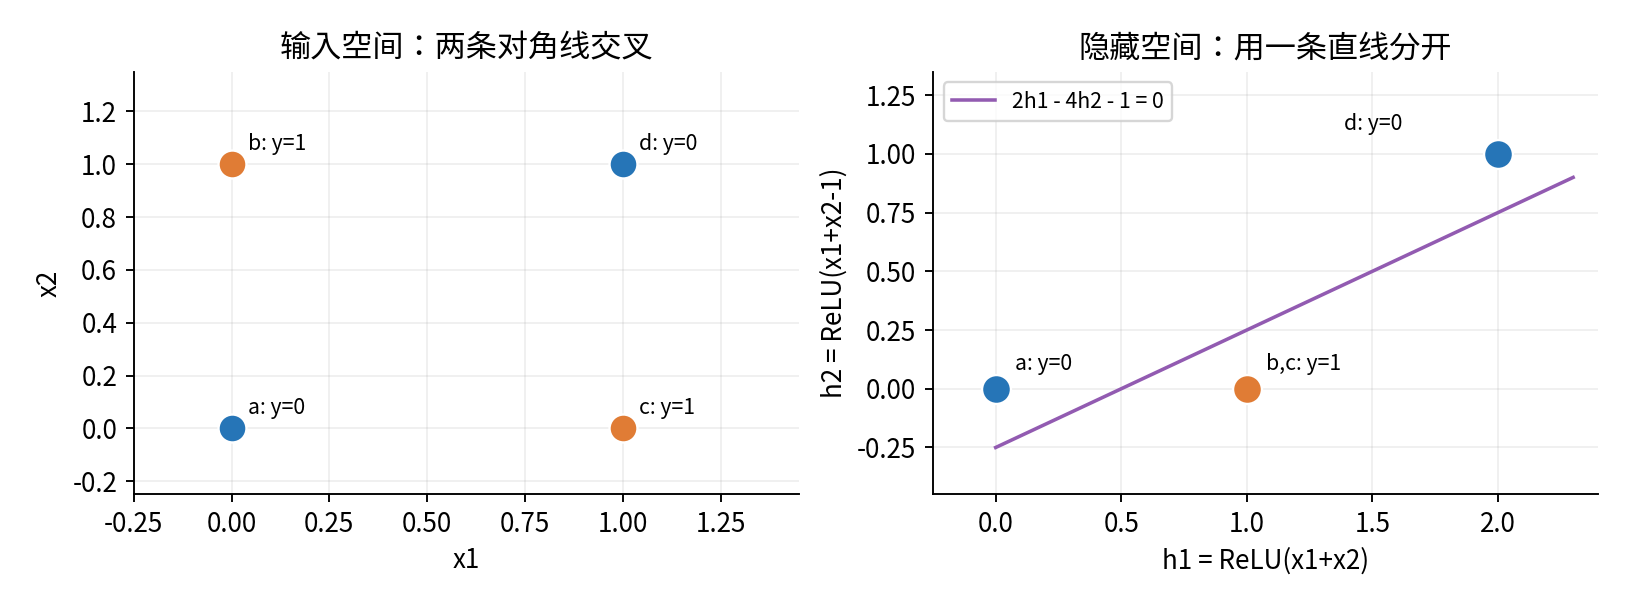

In [5]:
e.verify_teaching_artifacts()
from IPython.display import Image, display
display(Image(filename=str(e.ROOT / "figures/03_hidden_representation.png")))

### 5 移除隐藏非线性
只改激活方式，保持同一组权重和偏置。这个消融不是分别完成训练之后的比较。

In [6]:
e.verify_teaching_artifacts()
z_identity, _ = e.forward(X, layers, activation="identity")
W, b = e.collapse_affine(layers)
np.testing.assert_array_equal(z_identity, X @ W + b)
print("Collapsed W:", W.ravel(), "b:", b)
print("Identity logits:", z_identity[:, 0])
print("Identity metrics:", e.binary_metrics(z_identity[:, 0], y))

Collapsed W: [-2. -2.] b: [3.]
Identity logits: [ 3.  1.  1. -1.]
Identity metrics: {'loss': 0.9970931035321028, 'accuracy': 0.75}


### 6 125个仿射候选
每个参数各取5值，共125组；枚举得到的是该集合的最优。所有四点都参与选择。

In [7]:
e.verify_teaching_artifacts()
affine_rows = [r for r in result[2] if r["family"] == "affine"]
print("Candidate count:", len(affine_rows))
print("Minimum CE:", min(affine_rows, key=lambda r: r["loss"]))
print("Maximum accuracy:", max(r["accuracy"] for r in affine_rows))

Candidate count: 125
Minimum CE: {'family': 'affine', 'w1': 0, 'w2': 0, 'bias': 0, 'scale': '', 'loss': 0.6931471805599453, 'accuracy': 0.5}
Maximum accuracy: 0.75


### 7 只搜索输出尺度
隐藏表示固定，输出权重和偏置一起乘γ。不独立调整9个参数。

gamma = 0 loss = 0.6931471805599453 accuracy = 0.5
gamma = 1 loss = 0.31326168751822286 accuracy = 1.0
gamma = 2 loss = 0.1269280110429725 accuracy = 1.0
gamma = 4 loss = 0.018149927917809738 accuracy = 1.0
gamma = 8 loss = 0.00033540637289576885 accuracy = 1.0


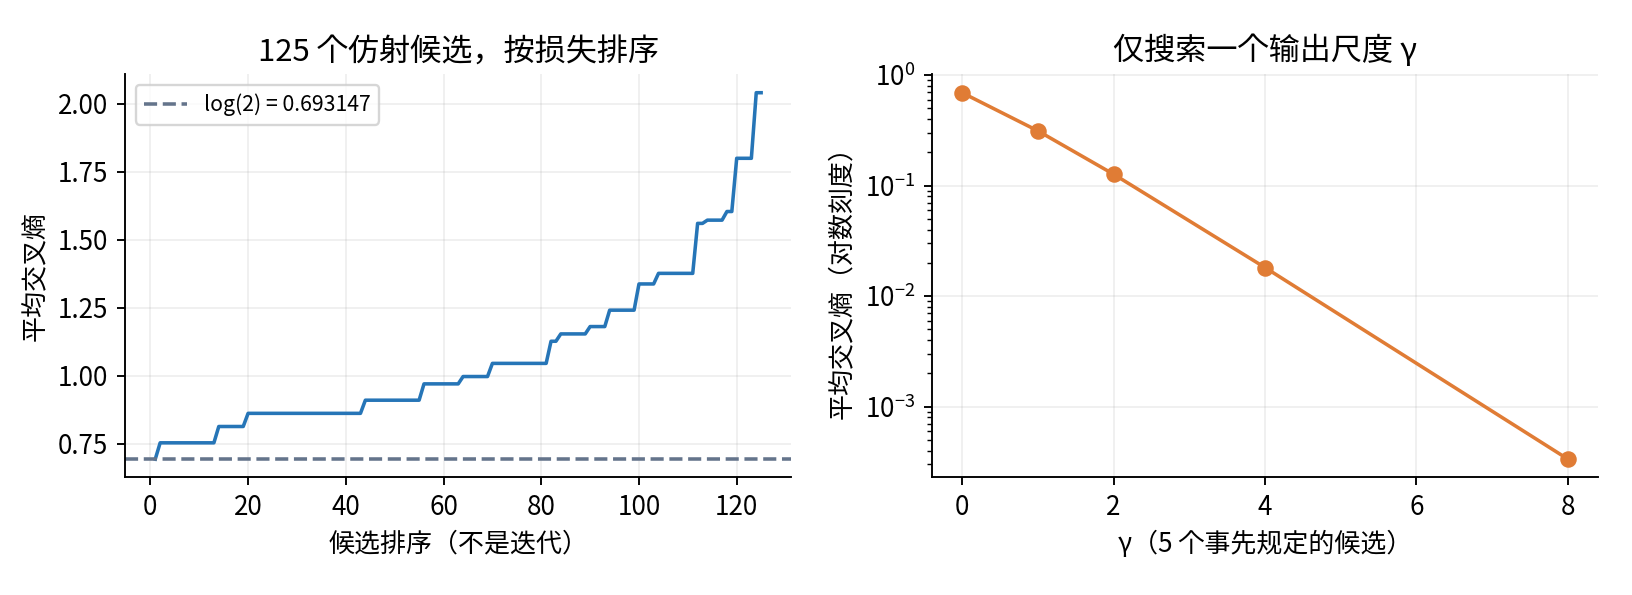

In [8]:
e.verify_teaching_artifacts()
for r in result[2][125:]:
    gamma = r["scale"]
    oracle = float(np.log1p(np.exp(-gamma)))
    assert np.isclose(r["loss"], oracle)
    print("gamma =", gamma, "loss =", r["loss"], "accuracy =", r["accuracy"])
display(Image(filename=str(e.ROOT / "figures/07_bounded_search.png")))

### 8 另一个同样拟合四角点的网络
用两个ReLU表示绝对差。没有内部标签，不能仅凭图判断哪种延伸正确。

Queries:
 [[0.5  0.5 ]
 [0.25 0.5 ]]
Rule A logits: [1.  0.5]
Rule B logits: [-1.  -0.5]


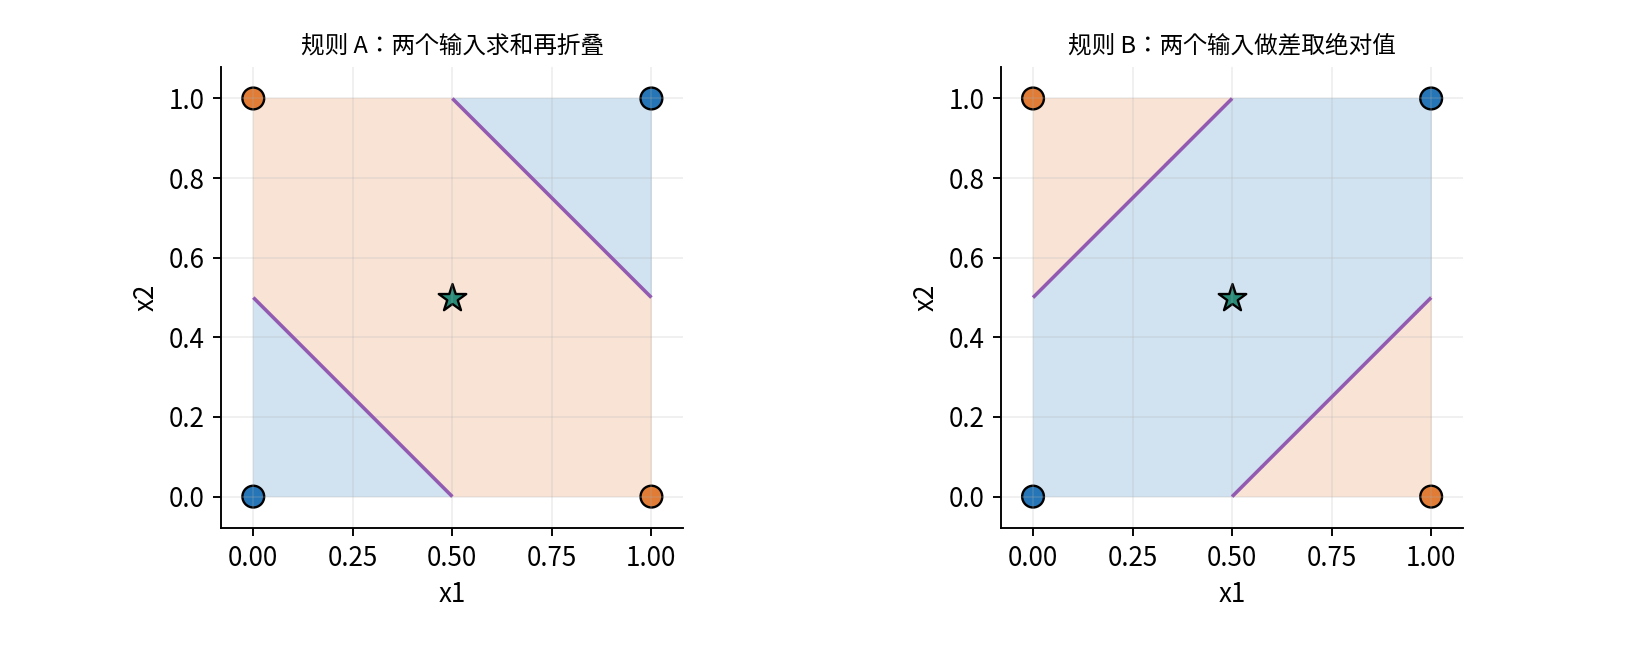

In [9]:
e.verify_teaching_artifacts()
other_layers = [
    (np.array([[1., -1.], [-1., 1.]]), np.zeros(2)),
    (np.array([[2.], [2.]]), np.array([-1.])),
]
z_other, _ = e.forward(X, other_layers)
np.testing.assert_array_equal(z_other, z)
queries = np.array([[0.5, 0.5], [0.25, 0.5]])
print("Queries:\n", queries)
print("Rule A logits:", e.forward(queries, layers)[0][:, 0])
print("Rule B logits:", e.forward(queries, other_layers)[0][:, 0])
display(Image(filename=str(e.ROOT / "figures/08_unseen_ambiguity.png")))

### 9 深度复合
每次输出都送入下一个三角模块。圆圈复合与平方不同。

In [10]:
e.verify_teaching_artifacts()
for depth in [1, 2, 3]:
    print("depth", depth, "T composition at 1/8:", e.triangle([0.125], depth))
print("Squared first output:", e.triangle([0.125], 1) ** 2)

depth 1 T composition at 1/8: [0.25]
depth 2 T composition at 1/8: [0.5]
depth 3 T composition at 1/8: [1.]
Squared first output: [0.0625]


## 检查
### 10 预期失败也要验证
没有异常反而应视为失败。每种错误只针对一个输入契约。

In [11]:
e.verify_teaching_artifacts()
def must_reject(fn):
    try:
        fn()
    except ValueError as error:
        print(type(error).__name__ + ": " + str(error))
    else:
        raise AssertionError("invalid input was accepted")
must_reject(lambda: e.forward([[True, 0]], layers))
must_reject(lambda: e.binary_metrics([0, 1], [[0], [1]]))
must_reject(lambda: e.triangle([1.01], 2))

ValueError: boolean is not a real-valued coordinate
ValueError: labels: nonempty real array with correct dimensions required
ValueError: t in [0,1] and integer depth 1..12 required


### 11 用独立数值参照检查
Fraction逐坐标计算，Decimal高精度损失、反射式三角复合和失败前不写文件检查都在测试脚本内。

In [12]:
e.verify_teaching_artifacts()
import io, unittest
import test_experiment
stream = io.StringIO()
suite = unittest.defaultTestLoader.loadTestsFromModule(test_experiment)
test_result = unittest.TextTestRunner(stream=stream, verbosity=0).run(suite)
assert test_result.wasSuccessful(), stream.getvalue()
print("Independent test groups passed:", test_result.testsRun)

Independent test groups passed: 12


### 12 写入与逐字节比较
只在输入、计算、完整序列化已通过后写入Notebook重跑目录。该目录可以删除，不属于必要课程材料。

In [13]:
e.verify_teaching_artifacts()
summary = e.run(e.ROOT / "notebook_outputs")
for name, data in expected.items():
    assert (e.ROOT / "notebook_outputs" / name).read_bytes() == data
    print(name, "byte-identical")

summary.json byte-identical
forward.csv byte-identical
search.csv byte-identical
depth.csv byte-identical


## 下一步
完成独立实验A至F，再阅读完整详解。实际验证了新Python进程中的顺序InProcessKernel执行，没有测试浏览器Jupyter界面、独立进程socket传输、新建Anaconda环境或跨平台安装。

本实验给出XOR可表示性证据，证明纯仿射分类限制，比较有限候选并展示未见点歧义。未执行九参数连续优化，未证明实际任务泛化，也未把通用逼近当作训练或样本效率保证。来源和条件见正文与source-checks.json。